In [16]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

In [30]:
df = pd.read_csv('/kaggle/input/datasets/nitikamaan15/tweets/Tweets.csv')

print(df.columns)

df = df[['text', 'sentiment']]
df.columns = ['text', 'label']

df = df.dropna()

Index(['textID', 'text', 'selected_text', 'sentiment'], dtype='object')


In [18]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

print(le.classes_)   # ['negative', 'neutral', 'positive']

['negative' 'neutral' 'positive']


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42
)

In [20]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(
    tokenizer.texts_to_sequences(X_train), maxlen=50
)

X_test_pad = pad_sequences(
    tokenizer.texts_to_sequences(X_test), maxlen=50
)

VOCAB_SIZE = 5000

In [21]:
models = {
    "RNN": Sequential([
        Embedding(VOCAB_SIZE, 64, input_length=50),
        SimpleRNN(64),
        Dense(3, activation='softmax')
    ]),
    
    "LSTM": Sequential([
        Embedding(VOCAB_SIZE, 64, input_length=50),
        LSTM(64),
        Dense(3, activation='softmax')
    ]),
    
    "GRU": Sequential([
        Embedding(VOCAB_SIZE, 64, input_length=50),
        GRU(64),
        Dense(3, activation='softmax')
    ])
}

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [22]:
for model in models.values():
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

In [23]:
history_dict = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    history = model.fit(
        X_train_pad, y_train,
        epochs=5,
        validation_data=(X_test_pad, y_test),
        verbose=1
    )
    
    history_dict[name] = history


Training RNN...
Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.4761 - loss: 1.0116 - val_accuracy: 0.6698 - val_loss: 0.7711
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.7445 - loss: 0.6279 - val_accuracy: 0.6698 - val_loss: 0.7943
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.8565 - loss: 0.3967 - val_accuracy: 0.6386 - val_loss: 0.9812
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9304 - loss: 0.2130 - val_accuracy: 0.6461 - val_loss: 1.1808
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9578 - loss: 0.1326 - val_accuracy: 0.6306 - val_loss: 1.4234

Training LSTM...
Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.5431 - loss: 0.9275 - val_accuracy: 0.6916 - val_loss: 0.7151
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.7570 - loss: 0.6014 - val_accuracy: 0.7111 - val_loss: 0.6883
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0

In [24]:
print("\nFinal Accuracy:")
for name, model in models.items():
    loss, acc = model.evaluate(X_test_pad, y_test)
    print(f"{name}: {acc:.4f}")


Final Accuracy:
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6341 - loss: 1.4093
RNN: 0.6306
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7172 - loss: 0.7385
LSTM: 0.7127
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7145 - loss: 0.7935
GRU: 0.7063


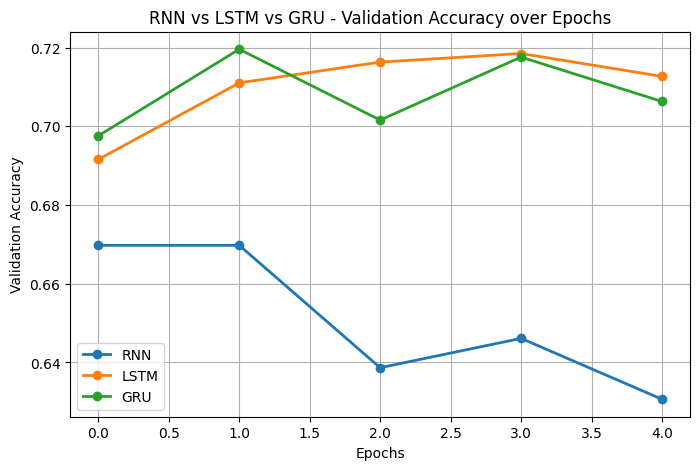

In [29]:
plt.figure(figsize=(8, 5))

for model_name, history in history_dict.items():
    plt.plot(
        history.history['val_accuracy'],
        marker='o',
        linewidth=2,
        label=model_name
    )

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("RNN vs LSTM vs GRU - Validation Accuracy over Epochs")
plt.grid(True)
plt.legend()

plt.show()